# KRUMA vs PyTorch: Comparative Analysis
This notebook runs the KRUMA Rust binaries directly via `cargo run`, captures their stdout, executes identical PyTorch routines, and generates comparative plots for Compute Time and Loss Convergence.

In [1]:
import torch
import torch.nn as nn
import time
import subprocess
import re
import os
import matplotlib.pyplot as plt

# Ensure we know where Cargo.toml is located relative to this notebook
cargo_root = ".." if os.path.exists("../Cargo.toml") else "."

print(f"Project root resolved to: {cargo_root}")

Project root resolved to: ..


### Experiment 1: Matrix Multiplication Benchmark

Compiling and running KRUMA Matmul benchmark...
Running PyTorch Matmul benchmark...


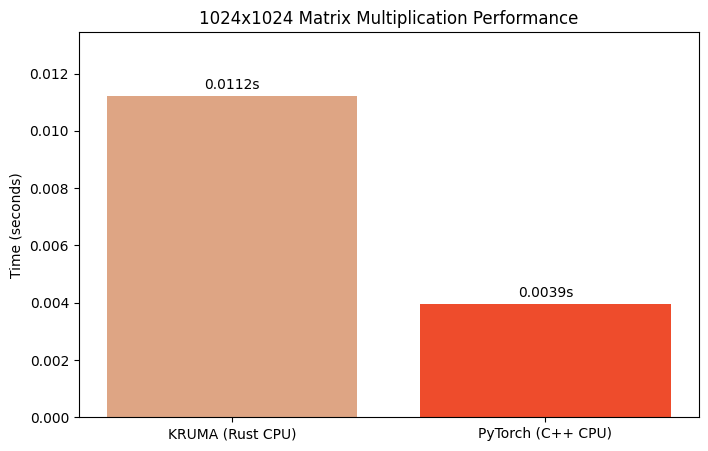

In [2]:
print("Compiling and running KRUMA Matmul benchmark...")
res = subprocess.run(["cargo", "run", "--release", "--bin", "matmul"], 
                     capture_output=True, text=True, cwd=cargo_root)

# Extract KRUMA execution time
kruma_match = re.search(r"KRUMA Time:\s+([\d\.]+)s", res.stdout)
kruma_time = float(kruma_match.group(1)) if kruma_match else 0.0

print("Running PyTorch Matmul benchmark...")
size = 1024
i_idx = torch.arange(size).view(-1, 1)
j_idx = torch.arange(size).view(1, -1)
data = ((i_idx + j_idx) % 100).float() * 0.01

a, b = data.clone(), data.clone()

start_time = time.time()
torch.matmul(a, b)
pytorch_time = time.time() - start_time

# ---------------- PLOTTING ----------------
plt.figure(figsize=(8, 5))
bars = plt.bar(['KRUMA (Rust CPU)', 'PyTorch (C++ CPU)'], [kruma_time, pytorch_time], 
               color=['#dea584', '#ee4c2c'])
plt.ylabel('Time (seconds)')
plt.title('1024x1024 Matrix Multiplication Performance')
plt.bar_label(bars, fmt='%.4fs', padding=3)

# Extend Y-axis slightly so labels fit
plt.ylim(0, max(kruma_time, pytorch_time) * 1.2)
plt.show()

### Experiment 2: XOR Challenge Convergence

Running KRUMA XOR training loop...
Running PyTorch XOR training loop...


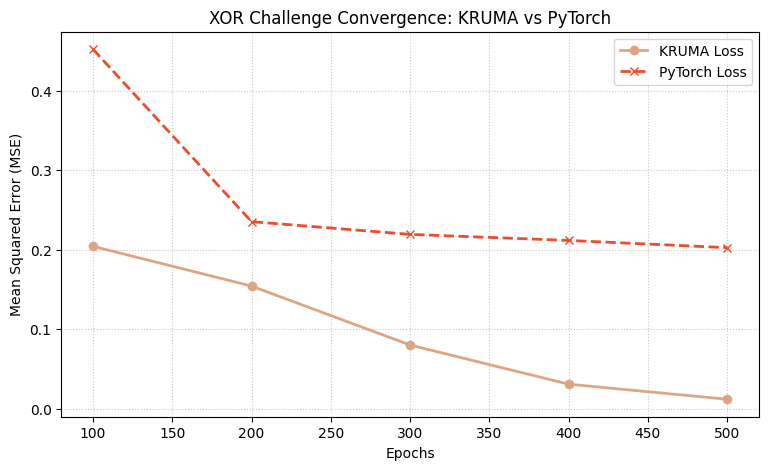

In [3]:
print("Running KRUMA XOR training loop...")
res = subprocess.run(["cargo", "run", "--release", "--bin", "xor"], 
                     capture_output=True, text=True, cwd=cargo_root)

# Extract epochs and losses from KRUMA stdout
kruma_data = re.findall(r"Epoch \[(\d+)/\d+\] Loss:\s+([\d\.]+)", res.stdout)
k_epochs = [int(x[0]) for x in kruma_data]
k_losses = [float(x[1]) for x in kruma_data]

print("Running PyTorch XOR training loop...")
x_train = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_train = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1), nn.Tanh())
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

p_epochs, p_losses = [], []
for epoch in range(1, max(k_epochs) + 1 if k_epochs else 501):
    optimizer.zero_grad()
    loss = criterion(model(x_train), y_train)
    loss.backward()
    optimizer.step()
    
    if epoch in k_epochs:
        p_epochs.append(epoch)
        p_losses.append(loss.item())

# ---------------- PLOTTING ----------------
plt.figure(figsize=(9, 5))
plt.plot(k_epochs, k_losses, label='KRUMA Loss', marker='o', linestyle='-', color='#dea584', linewidth=2)
plt.plot(p_epochs, p_losses, label='PyTorch Loss', marker='x', linestyle='--', color='#ee4c2c', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('XOR Challenge Convergence: KRUMA vs PyTorch')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()